In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/processed_dataset.csv")

df.head()

,text,label,text_length
0,The government should reduce taxes significant...,0,122
1,Cutting welfare programs is necessary to encou...,0,110
2,A strong military is essential for national se...,0,89
3,Deregulation is crucial to promote free market...,0,74
4,Traditional family values should be upheld to ...,0,82


In [3]:
X = df["text"]

y = df["label"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            max_features=10000,
            ngram_range=(1,2)
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])

In [6]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](5,)","[0,1,2,3,4]"
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",10000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


In [7]:
predictions = pipeline.predict(X_test)

In [8]:
accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.7398


In [9]:
print("Precision :", precision_score(y_test, predictions, average="weighted"))

print("Recall :", recall_score(y_test, predictions, average="weighted"))

print("F1 Score :", f1_score(y_test, predictions, average="weighted"))

Precision : 0.766309677357023
Recall : 0.7398373983739838
F1 Score : 0.7348252446924561


In [10]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      0.55      0.71        11
           1       0.64      0.90      0.74        39
           2       0.88      0.86      0.87        35
           3       0.61      0.48      0.54        23
           4       0.90      0.60      0.72        15

    accuracy                           0.74       123
   macro avg       0.81      0.68      0.72       123
weighted avg       0.77      0.74      0.73       123



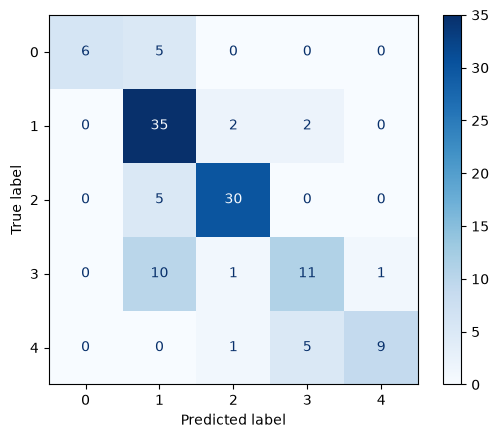

In [11]:
cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.show()

In [ ]:
sample = [
    "The government must invest more in universal healthcare and renewable energy."
]

prediction = pipeline.predict(sample)
Mydict={1 : "Centre-Right",2 : "Centre",0 : "Right",3 : "Centre-Left",4 : "Left"}
print("Predicted Label :", Mydict[prediction[0]])

Predicted Label : 3


In [13]:
import joblib

joblib.dump(pipeline, "../models/baseline_model.pkl")

print("Baseline model saved successfully!")

Baseline model saved successfully!
